In [1]:
import torch
import torch.nn.functional as F
import numpy as np

from model.architecture.basic_siamese import BasicSiameseModel
from model.architecture.advanced_siamese import AdvancedSiameseModel
from data_augmentation.matrices_loader import MatricesLoader
from visualization.data.weights_visualizator import WeightsVisualizator
from visualization.results.metrics_visualizator import MetricsVisualizator
from metrics.evaluator import Evaluator
from analytic_methods.EVM_method import EVM
from model.architecture.dense import DeepAHPNet
from utils.io_utils import load_model_weights_history
from utils.io_utils import load_test_matrices

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cuda
GPU: NVIDIA GeForce RTX 2060


In [12]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4, 0.45, 0.50]
CONSISTENCY_RATES_OLD = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4]

TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
NN_weights_predictions = {}
predicted_vectors_criteria = {}

In [4]:
def predict_single_weights_siamese(model: torch.nn.Module, matrix: np.ndarray, device: torch.device) -> np.ndarray:
    model = model.to(device)
    model.eval()

    tensor_matrix = torch.tensor(matrix, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrix + 1e-8)
    tensor_input = tensor_log.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        logits = model.encoder(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights = weights.squeeze(0).cpu().numpy()
    return final_weights


def predict_batch_weights_siamese(model: torch.nn.Module, matrices: np.ndarray, device: torch.device) -> np.ndarray:
    model = model.to(device)
    model.eval()

    tensor_matrices = torch.tensor(matrices, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrices + 1e-8)
    tensor_input = tensor_log.unsqueeze(1)

    with torch.no_grad():
        logits = model.encoder(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights_batch = weights.cpu().numpy()
    return final_weights_batch


def predict_batch_weights_dnn(model: torch.nn.Module, matrices: np.ndarray, device: torch.device) -> np.ndarray:
    model = model.to(device)
    model.eval()

    batch_size, n_criteria, _ = matrices.shape
    triu_i, triu_j = torch.triu_indices(n_criteria, n_criteria, offset=1)

    tensor_matrices = torch.tensor(matrices, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrices + 1e-8)
    tensor_input = tensor_log[:, triu_i, triu_j]

    with torch.no_grad():
        logits = model(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights_batch = weights.cpu().numpy()
    return final_weights_batch


def predict_batch_weights_graph(model: torch.nn.Module, matrices: np.ndarray, device: torch.device) -> np.ndarray:
    model = model.to(device)
    model.eval()

    tensor_matrices = torch.tensor(matrices, dtype=torch.float32).to(device)
    row_sums = tensor_matrices.sum(dim=2, keepdim=True)
    norm_matrices = tensor_matrices / row_sums

    with torch.no_grad():
        logits = model(norm_matrices)
        weights = F.softmax(logits, dim=1)

    final_weights_batch = weights.cpu().numpy()
    return final_weights_batch

In [5]:
def compare_results_single(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrix, weights_vector, pred_weights_vector in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vector, _ = solver.compute_single(test_matrix)
        mae_evm, kendall_taus_evm = evaluator.evaluate_single(weights_vector, evm_weights_vector)
        mae_nn, kendal_taus_nn = evaluator.evaluate_single(weights_vector, pred_weights_vector)

        all_mae_evm.append(mae_evm)
        all_kendall_taus_evm.append(kendall_taus_evm)
        all_mae_nn.append(mae_nn)
        all_kendall_taus_nn.append(kendal_taus_nn)

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)


def compare_results_batch(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrices, weights_vectors, pred_weights_vectors in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        mae_nn, kendal_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)

        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))
        all_mae_nn.append(np.mean(mae_nn))
        all_kendall_taus_nn.append(np.mean(kendal_taus_nn))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)


def compare_results_dict(solver, evaluator, matrices: dict, weights: dict, predicted_priority_weights: dict):
    cr_values = np.array(sorted(list(matrices.keys())))

    all_mae_evm = []
    all_kendall_taus_evm = []

    for cr in cr_values:
        test_matrices = matrices[cr]
        weights_vectors = weights[cr]
        
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        
        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)

    mae_errors_nn_list = []
    kendall_taus_nn_list = []
    nn_names_list = []

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(cr_values)} consistency rates.")
    print(f"Global mean CR: {np.mean(cr_values):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}")
    print("-" * 40)

    for nn_name, pred_cr_dict in predicted_priority_weights.items():
        nn_names_list.append(nn_name)
        all_mae_nn = []
        all_kendall_taus_nn = []

        for cr in cr_values:
            weights_vectors = weights[cr]
            pred_weights_vectors = pred_cr_dict[cr]

            mae_nn, kendall_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)
            
            all_mae_nn.append(np.mean(mae_nn))
            all_kendall_taus_nn.append(np.mean(kendall_taus_nn))

        final_mae_nn = np.array(all_mae_nn)
        final_kendall_taus_nn = np.array(all_kendall_taus_nn)

        mae_errors_nn_list.append(final_mae_nn)
        kendall_taus_nn_list.append(final_kendall_taus_nn)

        print(f"Network: {nn_name}")
        print(f"  -> Global mean MAE: {np.mean(final_mae_nn):.4f}")
        print(f"  -> Global mean Kendall correlation: {np.mean(final_kendall_taus_nn):.4f}")
        print("-" * 40)

    viz = MetricsVisualizator()
    viz.plot_comparison_lists(
        cr_values=cr_values,
        mae_errors_analytic=final_mae_evm,
        kendall_taus_analytic=final_kendall_taus_evm,
        mae_errors_nn=mae_errors_nn_list,
        kendall_taus_nn=kendall_taus_nn_list,
        nn_name=nn_names_list
    )

## Siamese Neural Network Evaluation

In [6]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "siamese"
LOSS_PARAM = "cop100_rec200_stab20_cons50"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"


model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_siamese(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/utils/io_utils.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, m

History and model: advanced_10000m_5crit_COP_optimized was loaded from models/siamese/cop100_rec200_stab20_cons50
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014

In [7]:
""" weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name) """

' weights_visualizator = WeightsVisualizator()\nnn_name = f"{MODEL_NAME.split(\'_\')[0]} {MODEL_TYPE}".title()\n\nfor cr_key in weights.keys():\n    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]\n    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()\n    weights_vector = weights.get(cr_key)[0].flatten()\n\n    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name) '


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0430
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6419


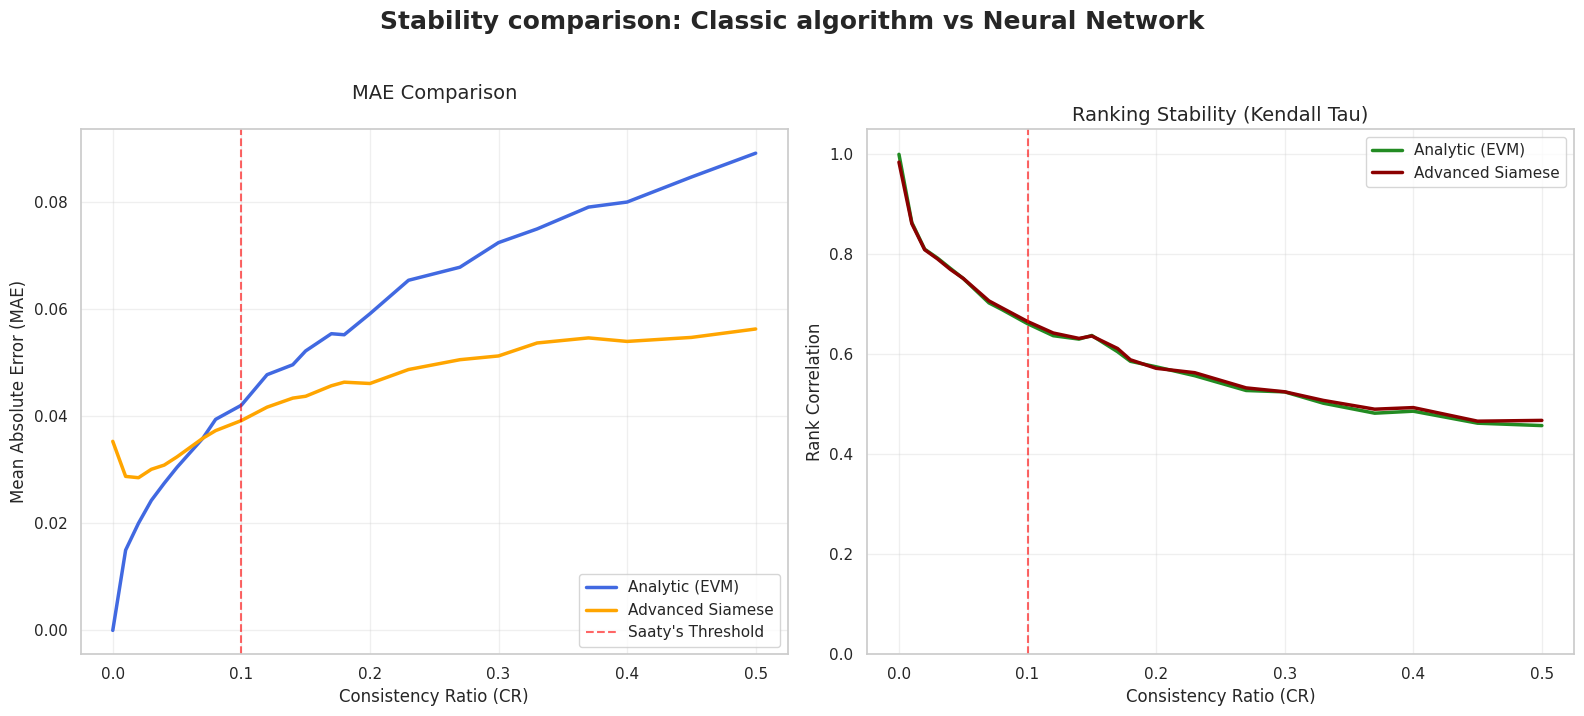

In [7]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

In [ ]:
NN_weights_predictions["Siamese, Weights COP"] = predicted_priority_weights
predicted

/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/utils/io_utils.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, m

History and model: advanced_10000m_5crit was loaded from models/siamese/cop200_rec300_stab10_cons50
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of cr

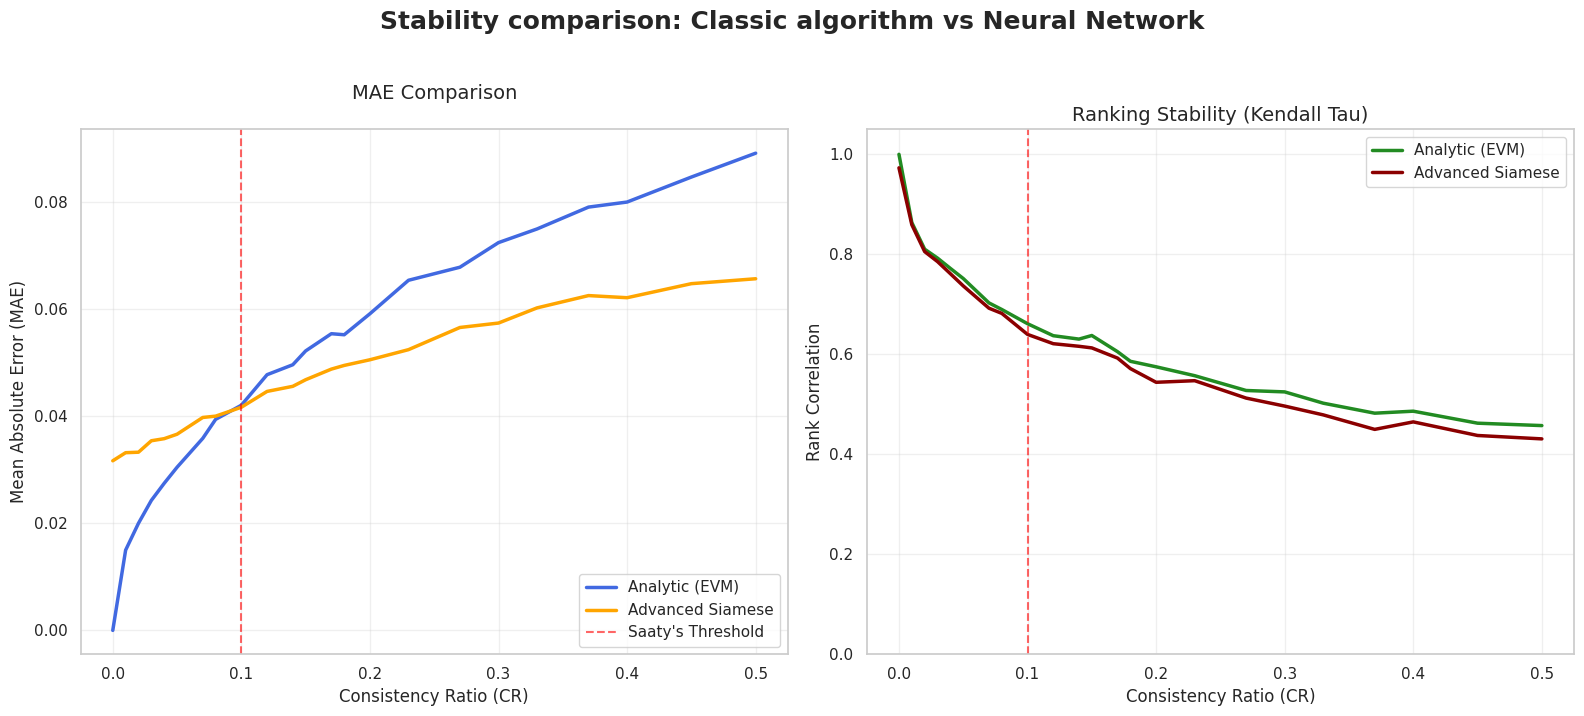

In [9]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "siamese"
LOSS_PARAM = "cop200_rec300_stab10_cons50"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"


model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_siamese(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508
Global mean Kendall correlation (EVM): 0.6398
----------------------------------------
Network: Siamese, Weights COP
  -> Global mean MAE: 0.0430
  -> Global mean Kendall correlation: 0.6419
----------------------------------------
Network: Siamese, Matrices COP
  -> Global mean MAE: 0.0476
  -> Global mean Kendall correlation: 0.6222
----------------------------------------


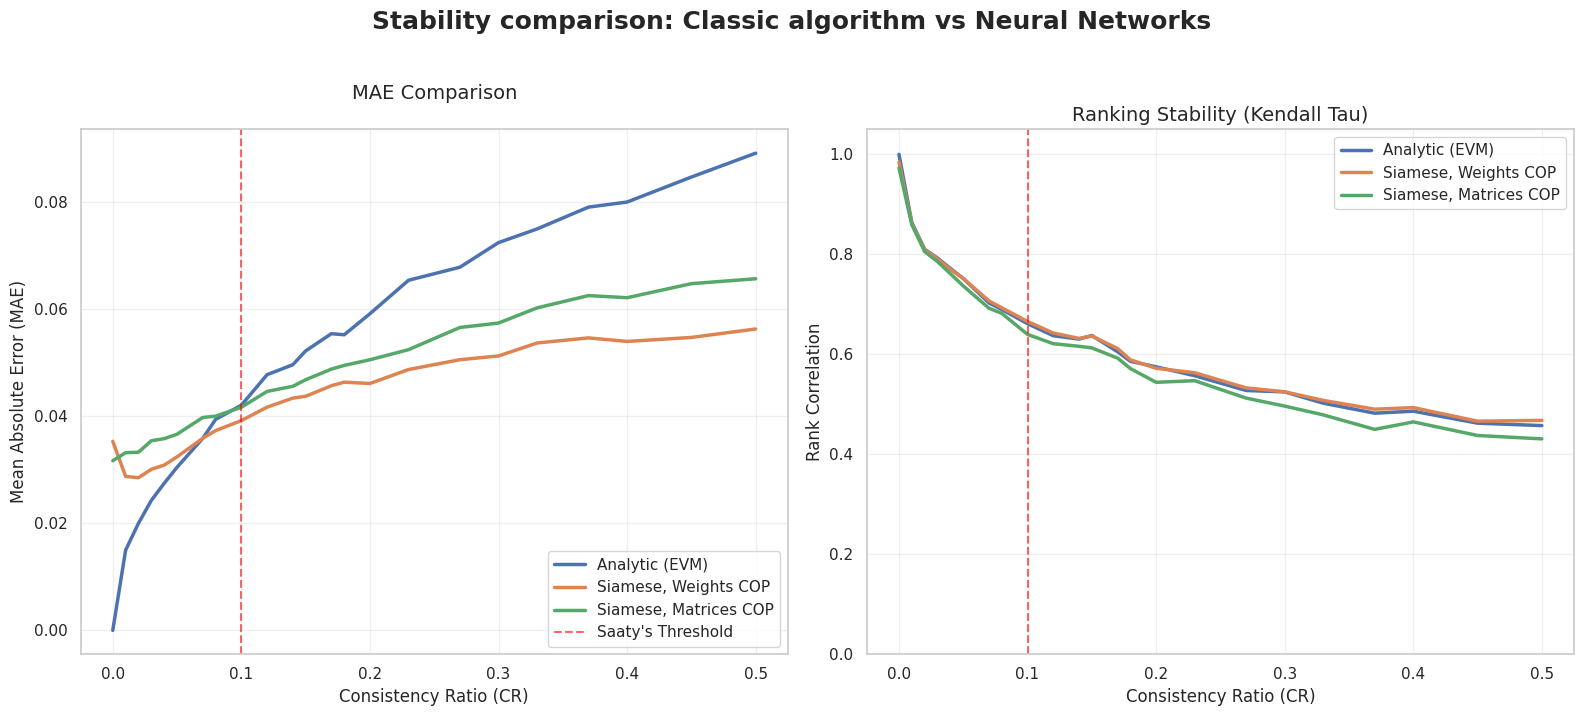

In [11]:
NN_weights_predictions["Siamese, Matrices COP"] = predicted_priority_weights
compare_results_dict(evm_solver, evaluator, matrices, weights, NN_weights_predictions)

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 5

MODEL_TYPE = "siamese"
LOSS_PARAM = "cop20_rec1000_stab250_cons400"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"


model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_siamese(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/utils/io_utils.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, m

History and model: advanced_10000m_5crit_COP_optimized was loaded from models/siamese/cop50_rec1000_stab250_cons400
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr0


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0575
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6424


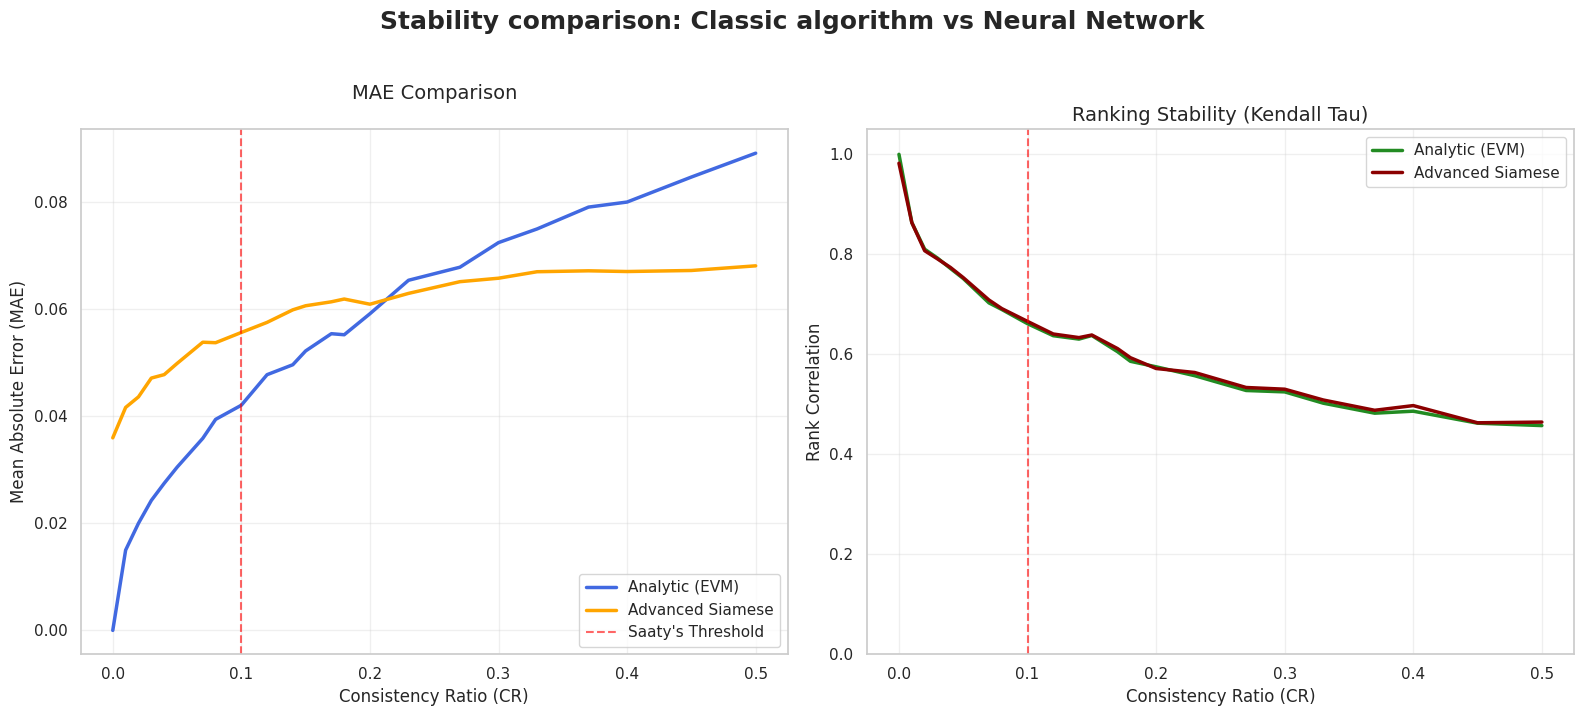

In [22]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

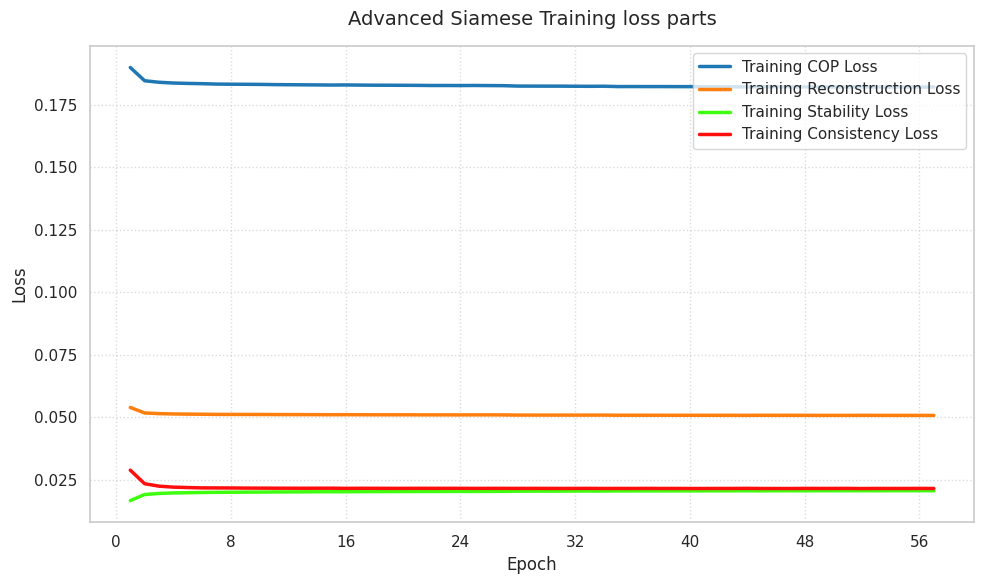

In [23]:
viz = MetricsVisualizator()
viz.display_part_losses(history, "Advanced Siamese")

### Criteria number comparison 

In [13]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "siamese"
LOSS_PARAM = "cop100_rec200_stab20_cons50"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"


model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_siamese(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")
predicted_vectors_criteria[f"Criteria {CRITERIA_NUM}"] = predicted_priority_weights

/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/utils/io_utils.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, m

History and model: advanced_10000m_5crit_COP_optimized was loaded from models/siamese/cop100_rec200_stab20_cons50
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014

In [14]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "siamese"
LOSS_PARAM = "cop100_rec200_stab20_cons50"
CRITERIA_NUM = 7
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"


model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_siamese(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")
predicted_vectors_criteria[f"Criteria {CRITERIA_NUM}"] = predicted_priority_weights

History and model: advanced_10000m_7crit_COP_optimized was loaded from models/siamese/cop100_rec200_stab20_cons50
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr014

In [20]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "siamese"
LOSS_PARAM = "cop100_rec200_stab20_cons50"
CRITERIA_NUM = 9
MODEL_NAME = f"advanced_20000m_{CRITERIA_NUM}crit_COP_optimized"


model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_siamese(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")
predicted_vectors_criteria[f"Criteria {CRITERIA_NUM}"] = predicted_priority_weights

History and model: advanced_20000m_9crit_COP_optimized was loaded from models/siamese/cop100_rec200_stab20_cons50
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 9).
Successfully uploaded 1000 noised matrices (level: cr014

In [21]:
compare_results_dict(evm_solver, evaluator, matrices, weights, predicted_vectors_criteria)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0211
Global mean Kendall correlation (EVM): 0.7247
----------------------------------------


ValueError: Batches shapes do not match: ! Ground Truth: (1000, 9), Predictions: (1000, 5)

## Graph Neural Network Evaluation

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "graph"
LOSS_PARAM = "cop200_rec300_stab10"
MODEL_NAME = f"basic_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = DeepAHPNet(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights_dnn(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights_graph(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

FileNotFoundError: Model file not found: models/graph/cop200_rec300_stab10/model_basic_10000m_5crit.pth

In [ ]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)

In [ ]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)